In [1]:
# importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### Importing all data files

In [2]:
df_heart = pd.read_csv('/content/heart.csv')

### Analysis and Modeling for Heart Disease

In [5]:
df_heart.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [6]:
df_heart.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [7]:
df_heart.shape

(918, 12)

In [8]:
df_heart.dtypes

,0
Age,int64
Sex,object
ChestPainType,object
RestingBP,int64
Cholesterol,int64
FastingBS,int64
RestingECG,object
MaxHR,int64
ExerciseAngina,object
Oldpeak,float64


In [9]:
df_heart.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [11]:
df_heart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [13]:
df_heart.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


### Visualization to get some insight from data

<ipython-input-16-1425092951>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_heart, x='HeartDisease', palette='Set2')


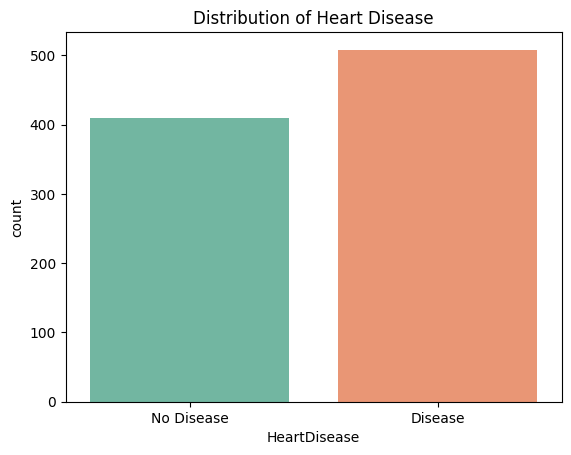

In [16]:
# ---- Heart Disease Class Distribution ----
sns.countplot(data=df_heart, x='HeartDisease', palette='Set2')
plt.title('Distribution of Heart Disease')
plt.xticks([0, 1], ['No Disease', 'Disease'])
plt.show()

Conclusion:

So we can see from above countplot the distribution of heart disease and most of them have it due to changing life style.

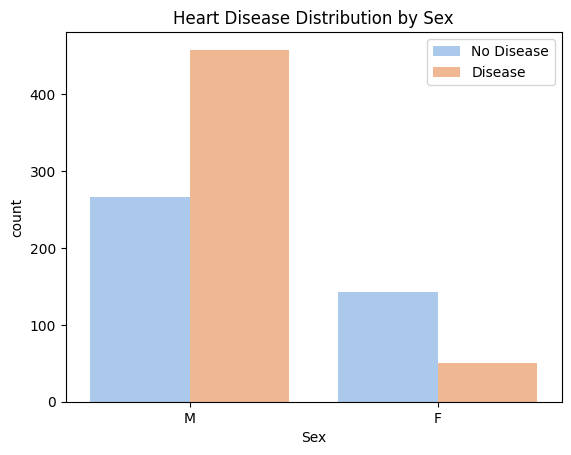

In [18]:
# ---- Heart Disease by Sex -----
sns.countplot(data=df_heart, x='Sex', hue='HeartDisease', palette='pastel')
plt.title('Heart Disease Distribution by Sex')
plt.legend(['No Disease', 'Disease'])
plt.show()

Conclusion:

We can see that most of the males have the heart disease

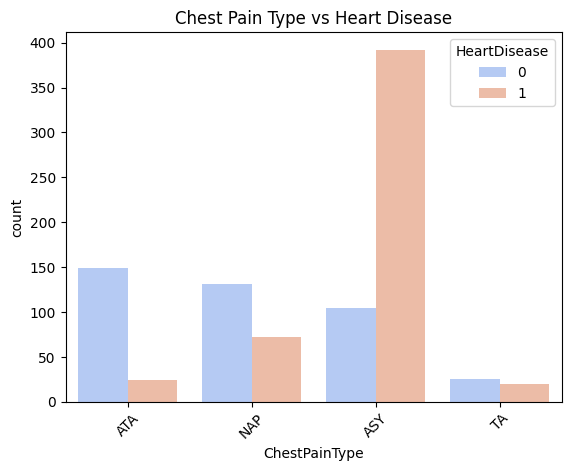

In [20]:
# ----- Chest Pain Type vs Heart Disease-----
sns.countplot(data=df_heart, x='ChestPainType', hue='HeartDisease', palette='coolwarm')
plt.title('Chest Pain Type vs Heart Disease')
plt.xticks(rotation=45)
plt.show()

Conclusion:

Analyze how chest pain types relate to heart disease.

Soo ChestPainType --> ASY leads most to heart disease.

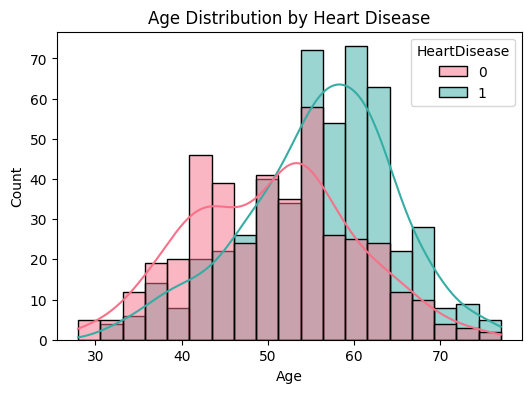

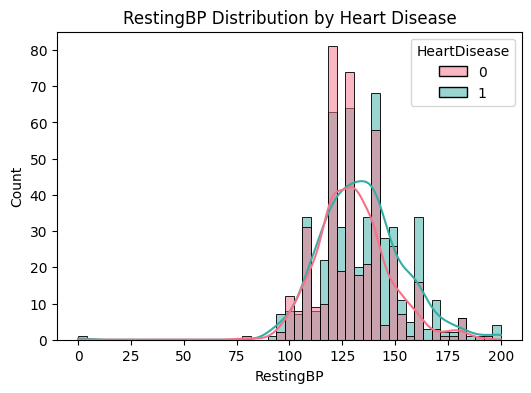

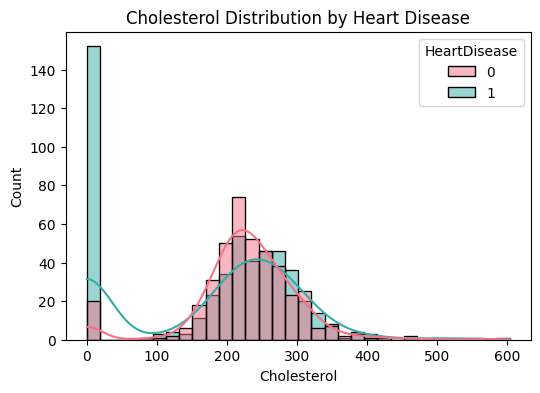

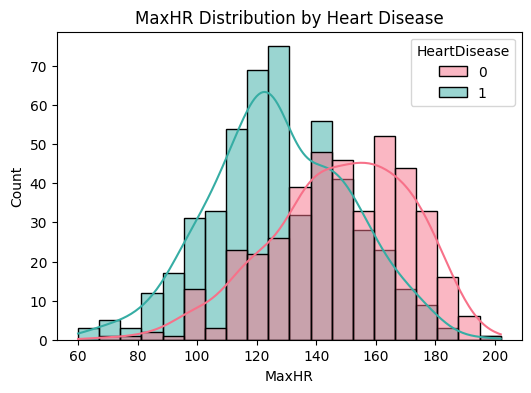

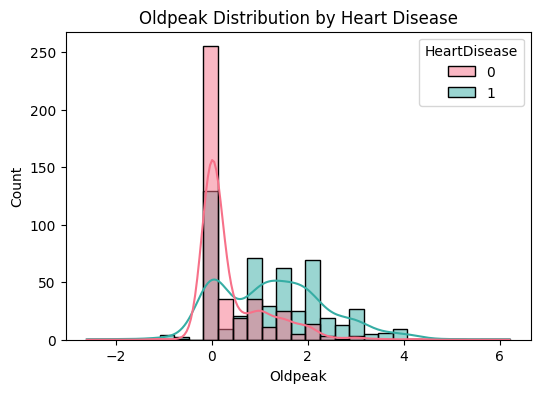

In [22]:
# ---- Numerical Feature Distribution by Heart Disease ----
num_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(data=df_heart, x=col, hue='HeartDisease', kde=True, palette='husl')
    plt.title(f'{col} Distribution by Heart Disease')
    plt.show()

Conclusion:

Soo From above plots we can see that:

Age --> Most of the elderly people have heart disease ranging from 50 to 90.

RestingBP --> The people with higher RestingBP generally have heart disease.

Cholestrol --> Data is missing a person cant have 0 cholestrol.

MaxHR --> People ranging from 60 to 140 in maxHr generally have heart disease.

OldPeak --> Ranging from 0 to 4 have heart disease.

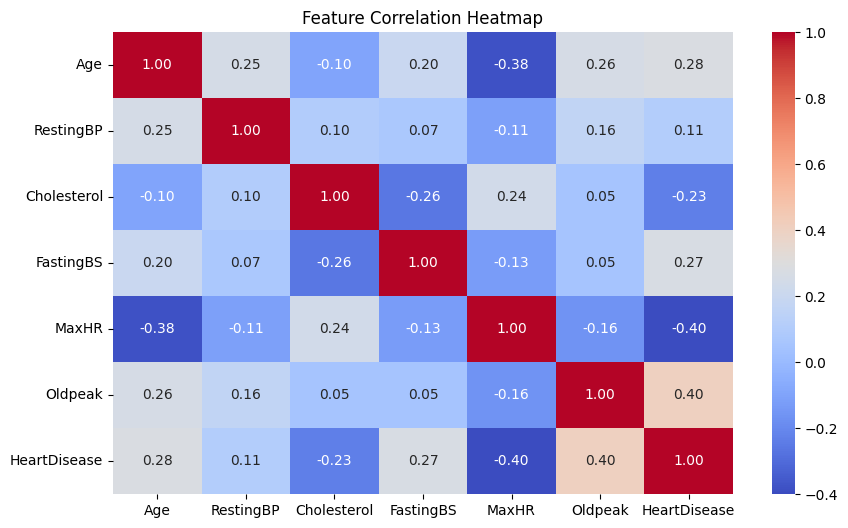

In [24]:
# ----  Correlation Heatmap ---
plt.figure(figsize=(10, 6))
sns.heatmap(df_heart.corr(numeric_only=True), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

### Encoding

In [26]:
# Label Encoding
df_heart['Sex'] = df_heart['Sex'].map({'M': 1, 'F': 0})
df_heart['ExerciseAngina'] = df_heart['ExerciseAngina'].map({'Y': 1, 'N': 0})

In [27]:
# One-Hot Encoding - for features with multiple categories
df_heart = pd.get_dummies(df_heart, columns=['ChestPainType', 'RestingECG', 'ST_Slope'], drop_first=True)

### Modeling

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [29]:
# 1. Feature and Target Split
X = df_heart.drop(['HeartDisease','Cholesterol'], axis=1)
y = df_heart['HeartDisease']

In [30]:
# 2. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [31]:
# 3. Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [32]:
# 4. Logistic Regression
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

print("🔹 Logistic Regression")
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

🔹 Logistic Regression
[[68  9]
 [16 91]]
              precision    recall  f1-score   support

           0       0.81      0.88      0.84        77
           1       0.91      0.85      0.88       107

    accuracy                           0.86       184
   macro avg       0.86      0.87      0.86       184
weighted avg       0.87      0.86      0.86       184



In [33]:
# 5. Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("🔹 Random Forest")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

🔹 Random Forest
[[65 12]
 [13 94]]
              precision    recall  f1-score   support

           0       0.83      0.84      0.84        77
           1       0.89      0.88      0.88       107

    accuracy                           0.86       184
   macro avg       0.86      0.86      0.86       184
weighted avg       0.86      0.86      0.86       184



In [34]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

print("🔹 KNN Classifier")
print(confusion_matrix(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))


🔹 KNN Classifier
[[66 11]
 [20 87]]
              precision    recall  f1-score   support

           0       0.77      0.86      0.81        77
           1       0.89      0.81      0.85       107

    accuracy                           0.83       184
   macro avg       0.83      0.84      0.83       184
weighted avg       0.84      0.83      0.83       184



In [35]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf', probability=True)
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)

print("🔹 SVM Classifier")
print(confusion_matrix(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))


🔹 SVM Classifier
[[67 10]
 [16 91]]
              precision    recall  f1-score   support

           0       0.81      0.87      0.84        77
           1       0.90      0.85      0.88       107

    accuracy                           0.86       184
   macro avg       0.85      0.86      0.86       184
weighted avg       0.86      0.86      0.86       184



In [36]:
import xgboost as xgb
from xgboost import XGBClassifier

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print("🔹 XGBoost Classifier")
print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [07:29:28] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


🔹 XGBoost Classifier
[[64 13]
 [23 84]]
              precision    recall  f1-score   support

           0       0.74      0.83      0.78        77
           1       0.87      0.79      0.82       107

    accuracy                           0.80       184
   macro avg       0.80      0.81      0.80       184
weighted avg       0.81      0.80      0.81       184



In [37]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

print("🔹 Gradient Boosting Classifier")
print(confusion_matrix(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))


🔹 Gradient Boosting Classifier
[[65 12]
 [15 92]]
              precision    recall  f1-score   support

           0       0.81      0.84      0.83        77
           1       0.88      0.86      0.87       107

    accuracy                           0.85       184
   macro avg       0.85      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184



### Feature Importance

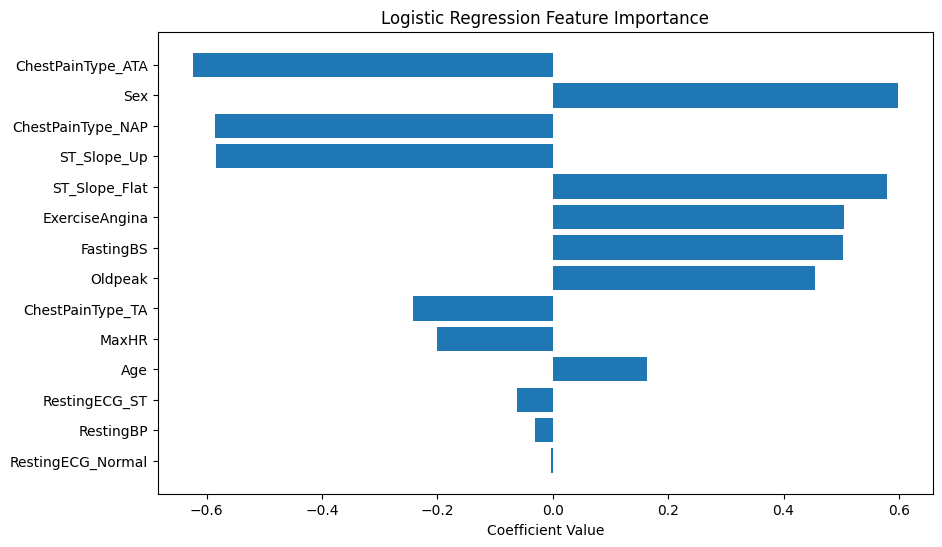

In [43]:

# Assume your features dataframe is X and target is y
# And logistic regression model is named `lr`

# Get feature names from your DataFrame columns
feature_names = X.columns

# Get coefficients from logistic regression model
coefficients = lr.coef_[0]

# Create DataFrame for easier plotting
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Sort by absolute value of coefficient
coef_df['abs_coef'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='abs_coef', ascending=False)

# Plot
plt.figure(figsize=(10,6))
plt.barh(coef_df['Feature'], coef_df['Coefficient'])
plt.xlabel('Coefficient Value')
plt.title('Logistic Regression Feature Importance')
plt.gca().invert_yaxis()
plt.show()


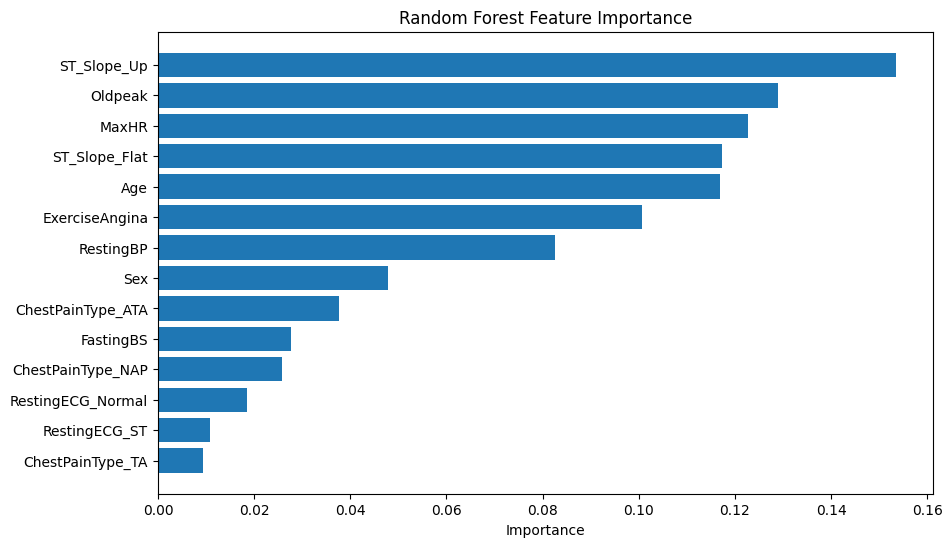

In [44]:
# Assume your random forest model is named `rf`

importances = rf.feature_importances_
feature_names = X.columns

importances_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

importances_df = importances_df.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10,6))
plt.barh(importances_df['Feature'], importances_df['Importance'])
plt.xlabel('Importance')
plt.title('Random Forest Feature Importance')
plt.gca().invert_yaxis()
plt.show()
